# 3. Semantic feature preparation

Configuration: `config/feature_creation/default.yaml`. This notebook inspects all text columns in the 20 core datasets. **No API calls, real feature creation, model training or Slurm submission.**

## 1. Feature-build scope

We plan two reusable numeric tables per dataset: one from reading text columns separately, and one from reading them together. That gives 40 table views across 20 datasets; it does not mean 40 features. The number of numeric columns depends on the task and number of text columns. With one text column, the two views coincide and share responses. Non-text features go only to the downstream prediction models.


,dataset_id,dataset,mode,include_non_text_features,rows,potential_slots,requests_before_deduplication,unique_requests_within_mode,new_requests_in_combined_build,empty_slots_skipped,retained_numeric_columns,proposed_compact_numeric_columns,status
0,BIN_TEXT_FAKE_JOB_POSTING,Fake Job Postings,per_column,False,12725,38175,27577,21958,21958,10598,3,3,planned_only
1,BIN_TEXT_FAKE_JOB_POSTING,Fake Job Postings,joint,False,12725,12725,12725,12674,12673,0,1,1,planned_only
2,BIN_TEXT_JIGSAW_TOXICITY,Jigsaw Toxicity,per_column,False,100000,100000,99999,99661,99661,1,1,1,planned_only
3,BIN_TEXT_JIGSAW_TOXICITY,Jigsaw Toxicity,joint,False,100000,100000,99999,99661,0,1,1,1,planned_only
4,BIN_TEXT_KICKSTARTER_FUNDING,Kickstarter,per_column,False,86502,259506,259499,258820,258820,7,3,3,planned_only
5,BIN_TEXT_KICKSTARTER_FUNDING,Kickstarter,joint,False,86502,86502,86502,86502,86501,0,1,1,planned_only
6,MUL_TEXT_DATA_SCIENTIST_SALARY,Data Scientist Salary,per_column,False,15841,79205,75696,30594,30594,3509,35,30,planned_only
7,MUL_TEXT_DATA_SCIENTIST_SALARY,Data Scientist Salary,joint,False,15841,15841,15841,12074,12074,0,7,6,planned_only
8,MUL_TEXT_MICHELIN_RESTAURANTS,Michelin Guide,per_column,False,18843,113058,111942,63756,63756,1116,36,30,planned_only
9,MUL_TEXT_MICHELIN_RESTAURANTS,Michelin Guide,joint,False,18843,18843,18843,18843,18843,0,6,5,planned_only


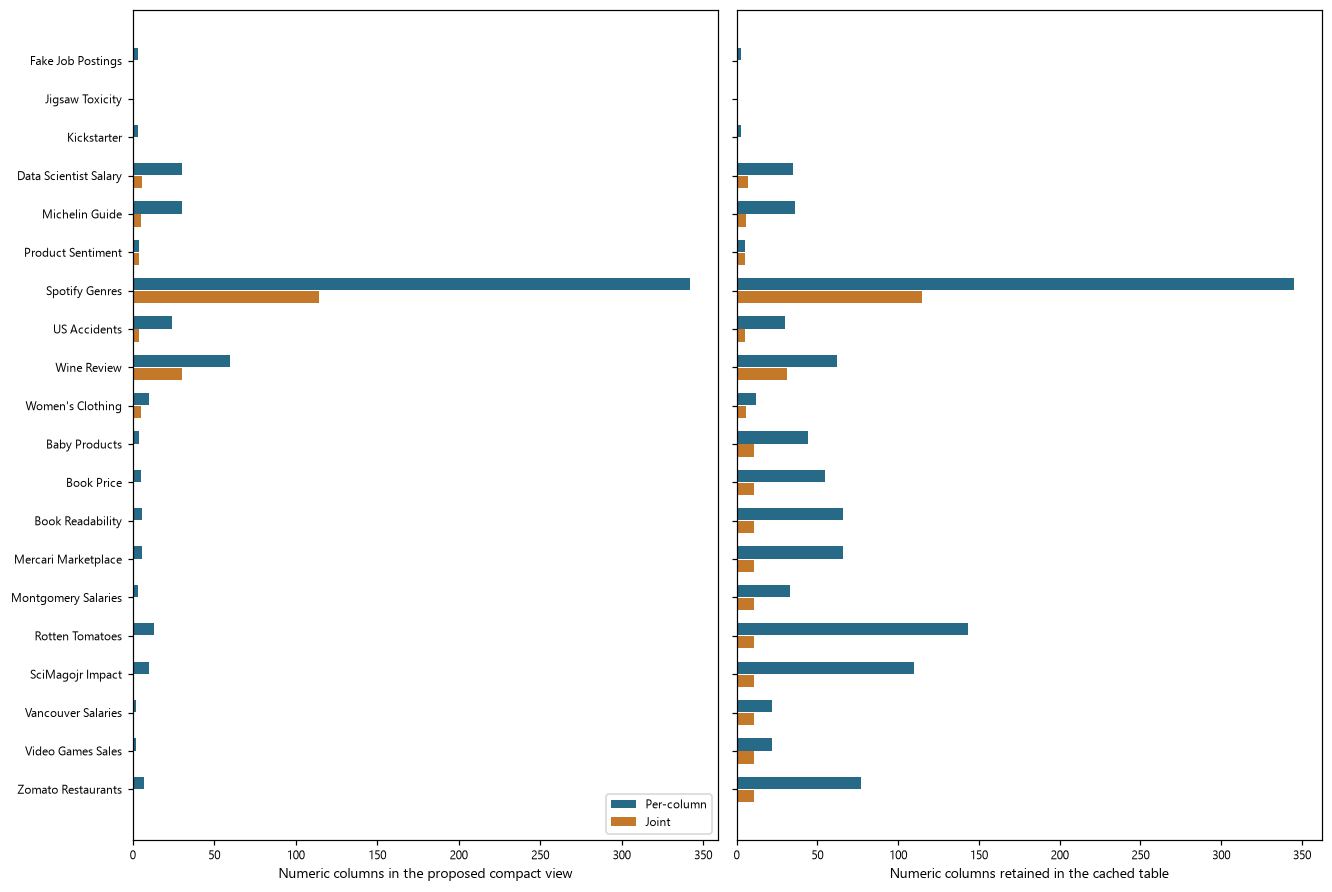

In [1]:
import sys
import json
import pandas as pd
from pathlib import Path
REPO_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file() and (p / "src").is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.utils.config import load_config, save_resolved_config
from src.utils.provenance import code_identity
from src.utils.notebook_display import display_json, display_local
from src.utils.paths import results_dir
from src.utils.serialization import write_json
from src.data.audit import audit_collection
from src.data.loaders import load_catalog
from src.jev.features import feature_plan, table_schemas, feature_summary
from src.jev.inspection import representative_requests
from src.jev.provider import api_preview
from src.jev.cost import estimate_workload, budget_scenarios, full_feature_budget
from src.visualize import figures, style

style.apply()
NOTEBOOK = "feature_creation/03_feature_creation"
from src.utils.notebook_report import begin_report, report_section, finish_report
begin_report()
report_section('1. Feature-build scope')
save = figures.FigureSaver(NOTEBOOK)
cfg = load_config("feature_creation/default")
config_hash = save_resolved_config(cfg, NOTEBOOK)
audit = audit_collection(cfg)
plan = feature_plan(audit, cfg)
display_local(plan)

import matplotlib.pyplot as plt
from src.visualize.feature_design import feature_dimensions_figure, request_counts_figure, workload_figure
fig, name, caption = feature_dimensions_figure(plan)
save(fig, name, caption=caption)
display_local(fig)
plt.close(fig)


## 2. API body preview

The pure mapping in `src/jev/provider.py` follows the [official API reference](https://docs.typesafe.ai/api), checked 2026-09-29. It does not send anything. The pinned reference model is `jev-1.13.0`; live response behaviour remains untested. Examples use the same deterministic builder as Notebook 2.

- Binary classification: Noul returns the probability supporting the mechanically oriented positive class.
- Multiclass: Choice preserves all class probabilities with stable IDs and an exact label mapping; it also returns confidence.
- Regression: Score accepts the nine ordered descriptions. Its indices are 0 through 8. Preserve all nine probabilities and confidence; an optional expected directional score is the probability-weighted index minus 4. Choosing which columns TabPFN receives remains an experiment-design decision.

No target value, target distribution, target quantile or fitted-model statistic enters a request.

In [2]:
report_section('2. API body preview')
requests = representative_requests(audit, cfg)
shown_tasks = set()
for request in requests:
    task = request.to_dict()["payload"]["state"]["task"]["task_type"]
    if task not in shown_tasks:
        display_json(f"Documentation-verified body: {task}", api_preview(request))
        shown_tasks.add(task)


## 3. Reusable tables

Future paid responses live in `data/jev_cache/responses.sqlite3`. Numeric features, row/request traces and manifests live under `data/jev_cache/features/<artifact_id>/`. Source row IDs (`csv:N`) remain stable across all experiments and folds. Targets stay separate.

An empty text input creates no request, a `missing_text` trace, and missing numeric features. For a nonempty input, a missing/invalid cached response is an error. Per-column names include `text_000`, `text_001`, etc.; joint names include `all_text`. Full probability vectors and confidence are retained so later feature comparisons need no extra API calls.


In [3]:
report_section('3. Reusable tables')
display_local(table_schemas())
display_json("Feature creation configuration", cfg["feature_creation"])


,table,key,content,scope
0,Raw source,dataset hash + csv:N,Original CSV and metadata; target remains here,One immutable dataset version
1,responses.sqlite3 / responses,request_key + namespace,"Exact state/question/settings, raw response, U...",Shared across all experiments
2,responses.sqlite3 / origins,request_key + origin hash,"Dataset, csv:N, text columns, code/config/sour...",Many origins may reuse one response
3,features.parquet,csv:N within artifact_id,One row per source row; numeric Jev columns only,One dataset and text representation
4,requests.parquet,csv:N + text group,Request key or missing_text status for each ro...,Trace feature cells to raw responses
5,manifest.json,artifact_id,"Model, templates, source/schema/code hashes, m...",Written last; complete artifact marker
6,Experiment feature matrix,csv:N,Original non-text columns joined with selected...,Targets separate; no API work during experiment


## 4. Workload and budget

Use actual encoded lengths from the full audit, with `ceil(characters / 4)`. This measures the intended state/question JSON, not Jev's exact tokenizer or billing wrappers. Count every logical slot before deduplication, after excluding empty inputs. Do not add the combined-mode rows to the per-column/joint rows: that would double-count work.

The reference price is USD 0.042 per million input tokens; output tokens are free according to the [model documentation](https://docs.typesafe.ai/models), checked 2026-09-30. Pricing and account limits must be rechecked before calls. The published 2,400 requests/minute (40/second) gives only an ideal lower bound on duration; actual throughput depends on latency, token limits, retries and the account.

The 32,000-token state-plus-longest-question limit makes some Zomato rows a blocking design issue. The screen below uses the character approximation and cannot prove API acceptance. No text is silently truncated, chunked or dropped. The full-volume budget remains a scenario until the overflow policy is agreed.

For a refined offline estimate, run `python -m src.jev.review` from the repository. It compares actual canonical feature values for cache reuse and counts the documented API-body JSON. The optional table below is displayed only when its source pins and configuration match. It excludes empty inputs but still includes over-limit inputs and remains a character-based estimate, not provider usage.

,mode,include_non_text_features,requests,input_tokens_approx,hypothetical_provider_overhead_tokens,cost_per_unit_price,input_cost_estimate,ideal_hours_at_reference_rpm
0,per_column,False,3164764,951569127,0,951.569127,39.965903,21.977528
1,joint,False,820403,395209845,0,395.209845,16.598813,5.697243
2,per_column_and_joint,False,3985167,1346778972,0,1346.778972,56.564717,27.674771


,dataset,mode,include_non_text_features,max_request_tokens_approx,requests_above_context_screen_approx
57,Zomato Restaurants,per_column,False,370210,631
58,Zomato Restaurants,joint,False,370273,643


,characters_per_token,logical_requests,skipped_empty_slots,requests_for_combined_build,wire_tokens_logical_approx,wire_tokens_combined_approx,cost_usd
0,3,3985167,98493,2032351,1845057676,1137512661,47.775532
1,4,3985167,98493,2032351,1384314371,853391404,35.842439
2,5,3985167,98493,2032351,1107839242,682901101,28.681846


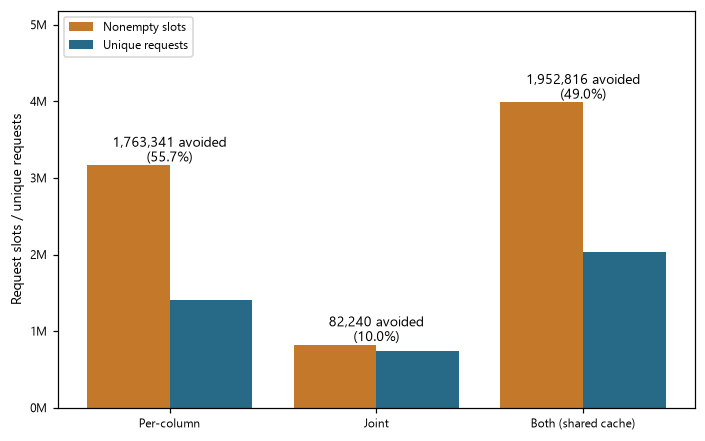

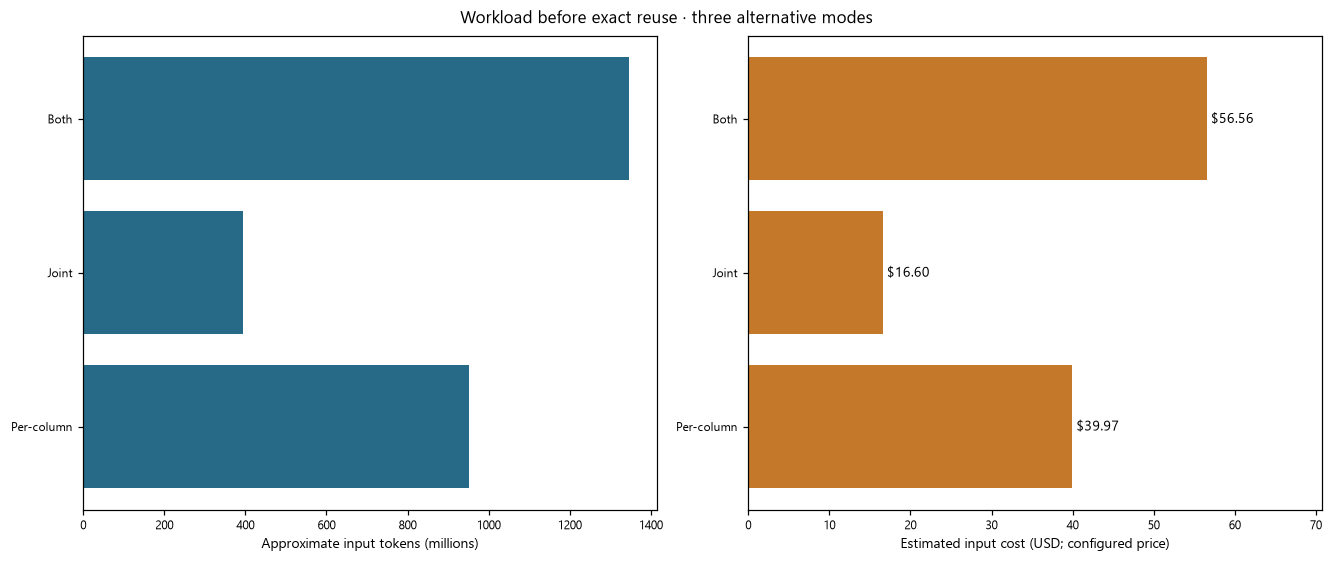

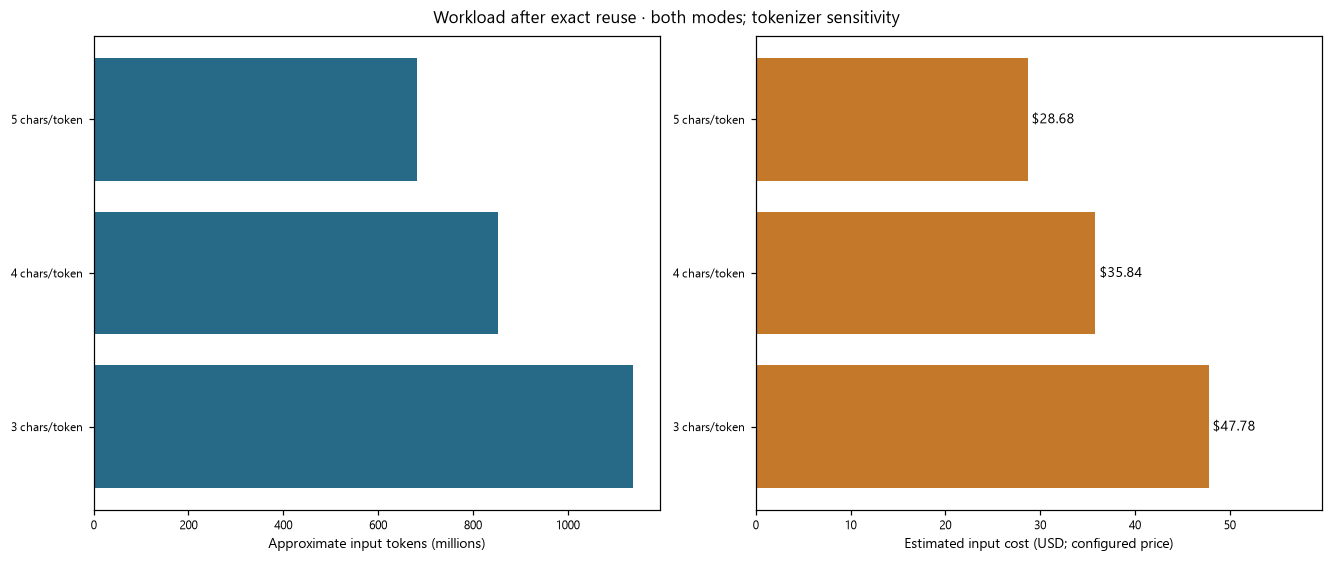

In [4]:
report_section('4. Workload and budget')
estimates = estimate_workload(audit, cfg)
totals = budget_scenarios(estimates, cfg)
full_budget = full_feature_budget(totals)
display_local(totals)
display_json("Both text representations, counted once", full_budget)
overflow = estimates[(estimates["mode"] != "per_column_and_joint") & (estimates.requests_above_context_screen_approx > 0)][["dataset", "mode", "include_non_text_features", "max_request_tokens_approx", "requests_above_context_screen_approx"]]
display_local(overflow)
budget_folder = results_dir(phase="feature_creation")
totals.to_csv(budget_folder / "budget_scenarios.csv", index=False)
overflow.to_csv(budget_folder / "context_screen.csv", index=False)
write_json(budget_folder / "full_budget.json", full_budget)

review_path = budget_folder / "review" / "manifest.json"
review_current = False
review_totals = None
if review_path.is_file():
    review_manifest = json.loads(review_path.read_text(encoding="utf-8"))
    expected_hashes = {entry["id"]: entry["sha256"] for entry in load_catalog(cfg["catalog"])["datasets"]}
    review_current = review_manifest["config"] == cfg and review_manifest["dataset_hashes"] == expected_hashes and review_manifest.get("code_sha256") == code_identity()
    if review_current:
        review_totals = pd.DataFrame(review_manifest["totals"])
        review_totals["cost_usd"] = review_totals.wire_tokens_combined_approx * cfg["cost"]["input_price_per_million"] / 1e6 if cfg["cost"]["input_price_per_million"] is not None else None
        display_local(review_totals)
        display_json("Illustrative pilot budget, no API requests", review_manifest["pilot"])
if not review_current:
    print("Refined budget absent or stale: run python -m src.jev.review to refresh it offline.")

for fig, name, caption in [request_counts_figure(audit.summary), workload_figure(totals)]:
    save(fig, name, caption=caption)
    display_local(fig)
    plt.close(fig)
if review_current:
    fig, name, caption = workload_figure(review_totals, deduplicated=True)
    save(fig, name, caption=caption)
    display_local(fig)
    plt.close(fig)


## 5. Execution sequence

Design review and local previews → small approved local Jev pilot → full local feature creation and validation → experiment 0 on VSC → experiment 1. Proposed experiment 1 compares non-text features with per-column, joint and both Jev additions across models. Experiment 2 examines original text with and without Jev. Experiment 3 compares numeric Jev output views. All use the same saved features and five outer folds. Jev connectivity on VSC is not required. All real API and model execution remains disabled.

## Summary

The final cell prints and saves every displayed table, request example, configuration, budget and figure detail.


In [5]:
finish_report(NOTEBOOK, feature_summary(plan, totals) + "\n" + save.summary())


feature_creation/03_feature_creation

1. Feature-build scope

                    dataset_id               dataset       mode  include_non_text_features   rows  potential_slots  requests_before_deduplication  unique_requests_within_mode  new_requests_in_combined_build  empty_slots_skipped  retained_numeric_columns  proposed_compact_numeric_columns       status
     BIN_TEXT_FAKE_JOB_POSTING     Fake Job Postings per_column                      False  12725            38175                          27577                        21958                           21958                10598                         3                                 3 planned_only
     BIN_TEXT_FAKE_JOB_POSTING     Fake Job Postings      joint                      False  12725            12725                          12725                        12674                           12673                    0                         1                                 1 planned_only
      BIN_TEXT_JIGSAW_TOXICITY     